<a href="https://colab.research.google.com/github/gulshan-katankar/language_modelling/blob/main/model_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [37]:
import requests

url = "https://raw.githubusercontent.com/gulshan-katankar/language_modelling/refs/heads/main/names.txt"

words = requests.get(url).text.splitlines()

In [4]:
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [38]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [43]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  x, y= [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      x.append(context)
      y.append(ix)
      context = context[1:] + [ix] # crop and append

  x = torch.tensor(x)
  y = torch. tensor(y)
  print(x.shape, y.shape)
  return x, y

import random
random. seed(42)
random. shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
xtr, ytr = build_dataset(words [:n1])
xdev, ydev = build_dataset (words [n1:n2] )
xte, yte = build_dataset(words [n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [15]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn( (vocab_size, n_embd), generator=g)
W1 = torch.randn( (n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch. randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p. requires_grad = True

11897


In [16]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = xtr[ix], ytr[ix] # batch X, Y

  # forward pass|
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3148
  10000/ 200000: 2.6505
  20000/ 200000: 2.4705
  30000/ 200000: 2.0266
  40000/ 200000: 2.1797
  50000/ 200000: 2.4072
  60000/ 200000: 2.2316
  70000/ 200000: 2.0701
  80000/ 200000: 2.0010
  90000/ 200000: 2.0439
 100000/ 200000: 2.4564
 110000/ 200000: 2.2124
 120000/ 200000: 2.1843
 130000/ 200000: 2.2414
 140000/ 200000: 2.1447
 150000/ 200000: 2.2837
 160000/ 200000: 2.0286
 170000/ 200000: 2.0146
 180000/ 200000: 2.2178
 190000/ 200000: 2.0372


before: 0/ 200000: 27.789

the loss we are getting at initialisation is clearly out of the visible scope, at initial stage we would expect the model to perform worse and treat all the 27 char equal, and if we calculate the rough loss for it :

In [10]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

we got 3.29 which is much smaller than the loss we are getting so theres definately something wrong with the initialisation

one of the common reasons of this is the logits which comes out of the neural networks have very high values and they arent normally distributed at the initialisation step, these logits should be closer to 0

so to handle this we alter with the w2 and b2

after : 0/ 200000: 3.3148

the below two graphs shows before and after results, we are no longer getting down from a very high loss, no hockey stick pattern

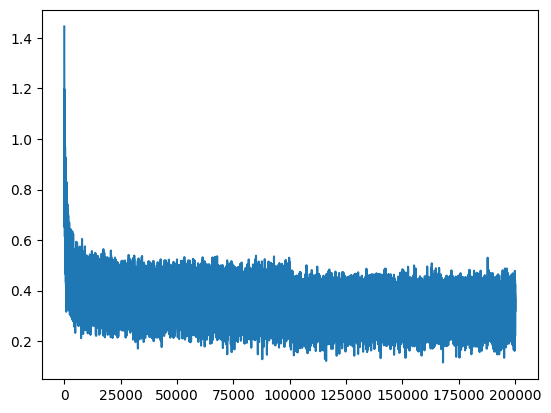

In [11]:
plt.plot(lossi)

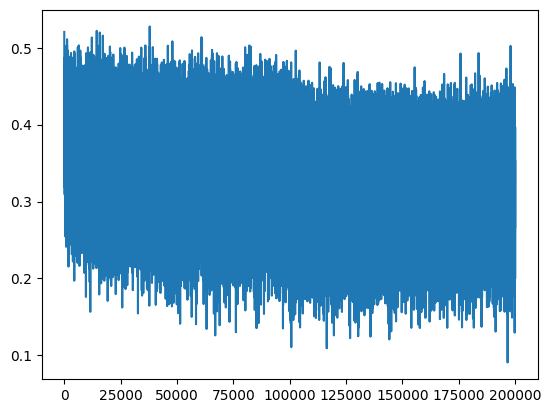

In [17]:
plt.plot(lossi)

In [20]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y ={
  'train': (xtr, ytr),
  'val': (xdev, ydev),
  'test': (xte, yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.069324493408203
val 2.133208751678467


before :
train 2.127678871154785
val 2.1750576496124268

after:
train 2.069324493408203
val 2.133208751678467

In [13]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

  out = []
  context = [0] * block_size # initialize with all
  while True:
    # forward pass the neural net
    emb = C[torch.tensor([context])] # (1,block_size,n_embd)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    # sample from the distribution
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    # shift the context window and track the samples
    context = context[1:] + [ix]
    out.append(ix)
    # if we sample the special '.' token, break
    if ix == 0:
      break

  print(''. join(itos[i] for i in out)) # decode and print the generated word

carlah.
amille.
khy.
myli.
taty.
skanden.
jazonen.
amerynchireei.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quint.
salin.
alianni.
wanthoniearyn.
kai.
everusabee.
demiia.


**fixing the hidden layer**

In [18]:
h

tensor([[-1.0000,  0.9252, -0.3721,  ...,  0.4169,  1.0000,  1.0000],
        [-0.9944, -0.9996, -1.0000,  ..., -0.9999,  1.0000,  0.6736],
        [ 1.0000, -1.0000, -0.9425,  ..., -0.9998, -0.7022, -0.9991],
        ...,
        [-1.0000,  0.9999, -1.0000,  ...,  1.0000, -1.0000,  0.0885],
        [-1.0000,  0.9252, -0.3721,  ...,  0.4169,  1.0000,  1.0000],
        [-0.9998, -0.9853,  1.0000,  ..., -1.0000,  0.9997,  1.0000]],
       grad_fn=<TanhBackward0>)

(array([2217.,  139.,   94.,   79.,   52.,  100.,   35.,   16.,   30.,
          33.,   27.,   19.,   18.,   14.,   15.,   33.,   28.,    7.,
          35.,   13.,   12.,   22.,   26.,   20.,   24.,   25.,    8.,
          15.,   11.,   33.,   20.,   11.,   13.,   12.,   15.,   24.,
          22.,   22.,   29.,   18.,   30.,   26.,   34.,   35.,   74.,
          65.,   82.,   56.,  138., 2474.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

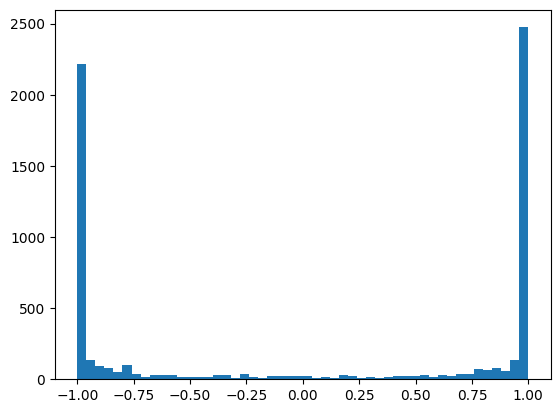

In [19]:
plt.hist(h.view(-1).tolist(), 50)

most of the values are -1 or 1 so this tanh is very much active

during the backprop the gradient for tanh will be 0 for most of the cases coz the derivative is 1-t^2 so it wont having any effect on the loss function

to solve this we will alter with the b1 and w1 this time, coz the hidden layer preactivation comes from embcat, b1 and w1, and embcat is already a uniform distribution

In [21]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn( (vocab_size, n_embd), generator=g)
W1 = torch.randn( (n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch. randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p. requires_grad = True

11897


In [25]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = xtr[ix], ytr[ix] # batch X, Y

  # forward pass|
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2790
  10000/ 200000: 2.3650
  20000/ 200000: 2.1157
  30000/ 200000: 2.3467
  40000/ 200000: 2.5888
  50000/ 200000: 2.1735
  60000/ 200000: 2.3252
  70000/ 200000: 1.9466
  80000/ 200000: 2.1100
  90000/ 200000: 2.1937
 100000/ 200000: 2.2151
 110000/ 200000: 1.8840
 120000/ 200000: 2.3478
 130000/ 200000: 2.2299
 140000/ 200000: 1.9127
 150000/ 200000: 2.2888
 160000/ 200000: 1.9301
 170000/ 200000: 2.1024
 180000/ 200000: 2.1640
 190000/ 200000: 1.7578


we got a better loss and the hidden layer is fixed too

(array([  8.,  11.,  19.,  48.,  48.,  65.,  93., 112.,  88., 103., 123.,
        141., 140., 151., 151., 158., 160., 164., 175., 192., 182., 186.,
        155., 171., 170., 189., 231., 189., 202., 171., 184., 169., 176.,
        192., 140., 166., 164., 164., 179., 133., 130.,  95., 126., 108.,
         88.,  66.,  36.,  43.,  29.,  16.]),
 array([-0.95887482, -0.92055975, -0.88224467, -0.8439296 , -0.80561452,
        -0.76729945, -0.72898438, -0.6906693 , -0.65235423, -0.61403915,
        -0.57572408, -0.537409  , -0.49909393, -0.46077885, -0.42246378,
        -0.38414871, -0.34583363, -0.30751856, -0.26920348, -0.23088841,
        -0.19257333, -0.15425826, -0.11594318, -0.07762811, -0.03931304,
        -0.00099796,  0.03731711,  0.07563219,  0.11394726,  0.15226234,
         0.19057741,  0.22889249,  0.26720756,  0.30552263,  0.34383771,
         0.38215278,  0.42046786,  0.45878293,  0.49709801,  0.53541308,
         0.57372816,  0.61204323,  0.6503583 ,  0.68867338,  0.72698845,
 

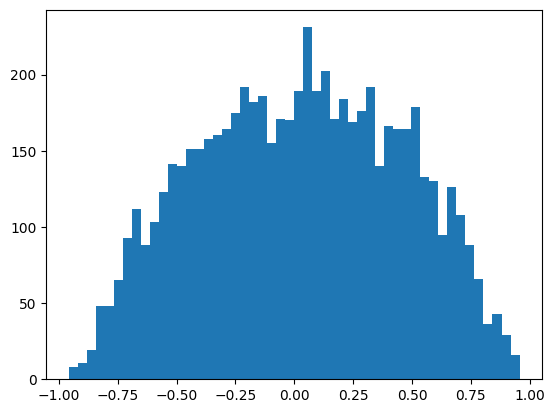

In [24]:
plt.hist(h.view(-1).tolist(), 50)

In [26]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y ={
  'train': (xtr, ytr),
  'val': (xdev, ydev),
  'test': (xte, yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0617597103118896
val 2.109034776687622


the train and val loss got much better

**HOW DO WE DECIDE WHAT VALUE TO MULTIPLY**

tensor(0.0027) tensor(0.9965)
tensor(-0.0109) tensor(3.1575)


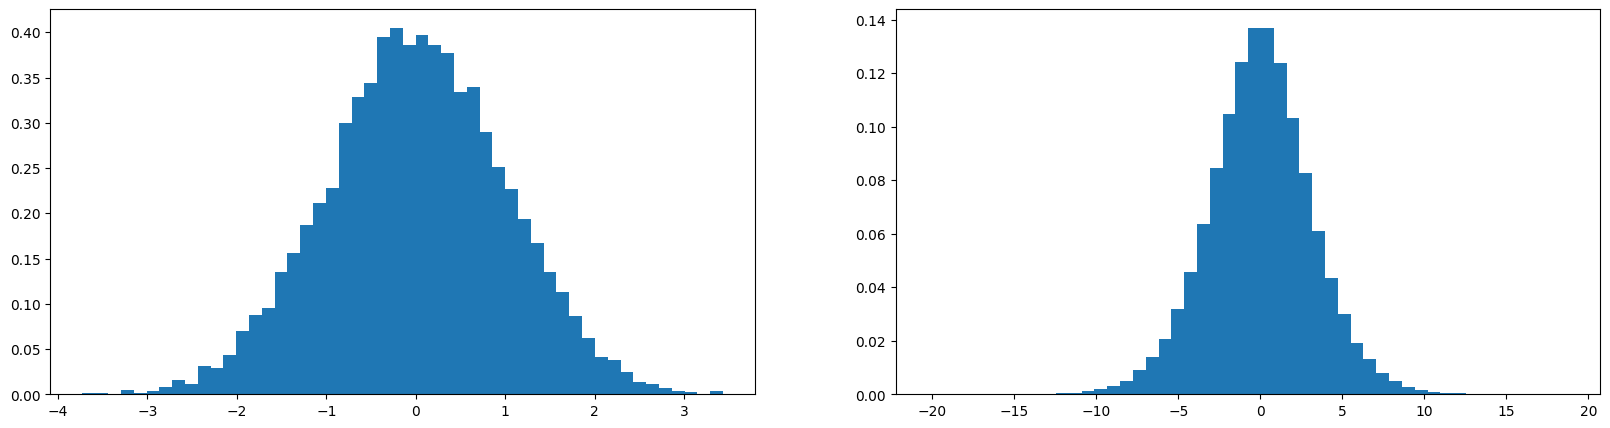

In [28]:
x = torch.randn(1000, 10) #1000 no with 10 dimensions
w = torch.randn(10, 200) #10 inputs, 200 neurons
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

for x we have a mean of 0 and sd of 1, sd is just the spread of the gaussian

now if we see y the mean remains almost the same but the sd changes and it isnt a gaussian anymore

tensor(-0.0077) tensor(1.0018)
tensor(-0.0179) tensor(47.6136)


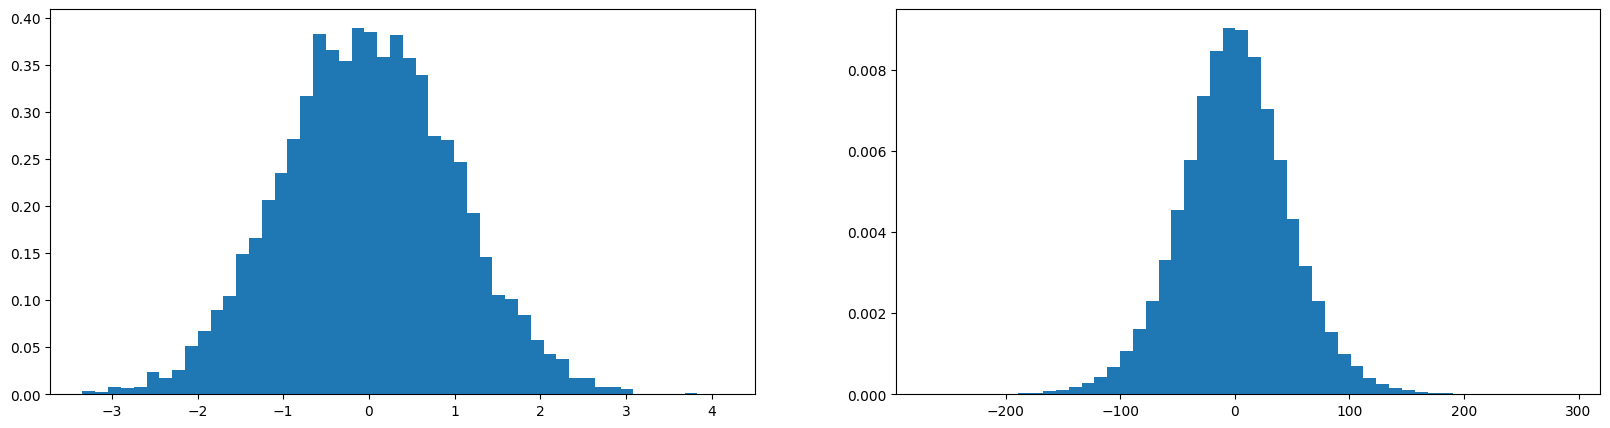

In [29]:
x = torch.randn(1000, 10) #1000 no with 10 dimensions
w = torch.randn(10, 200)  * 15
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

it got worse with 15 the distribution expanded more

tensor(0.0019) tensor(1.0076)
tensor(-0.0007) tensor(0.6506)


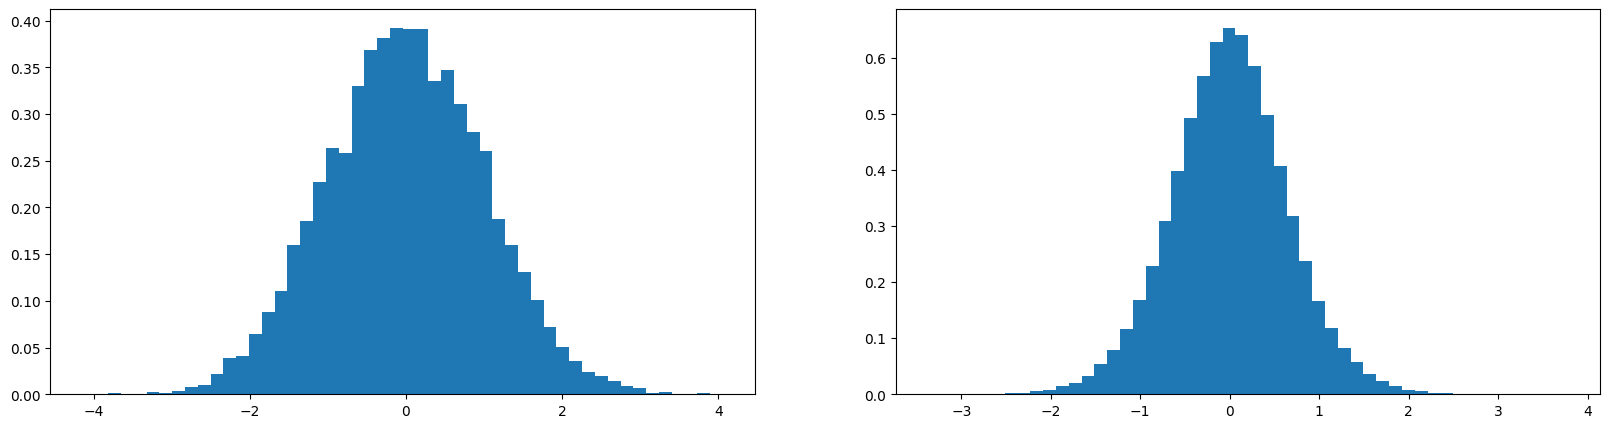

In [30]:
x = torch.randn(1000, 10) #1000 no with 10 dimensions
w = torch.randn(10, 200) * 0.2
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

ok so now the gaussian on the right is getting smaller, its shrinking

the mathematically correct way to achieve a perfect 1 is to divide by inputs square root

tensor(-0.0179) tensor(0.9965)
tensor(-0.0004) tensor(1.0151)


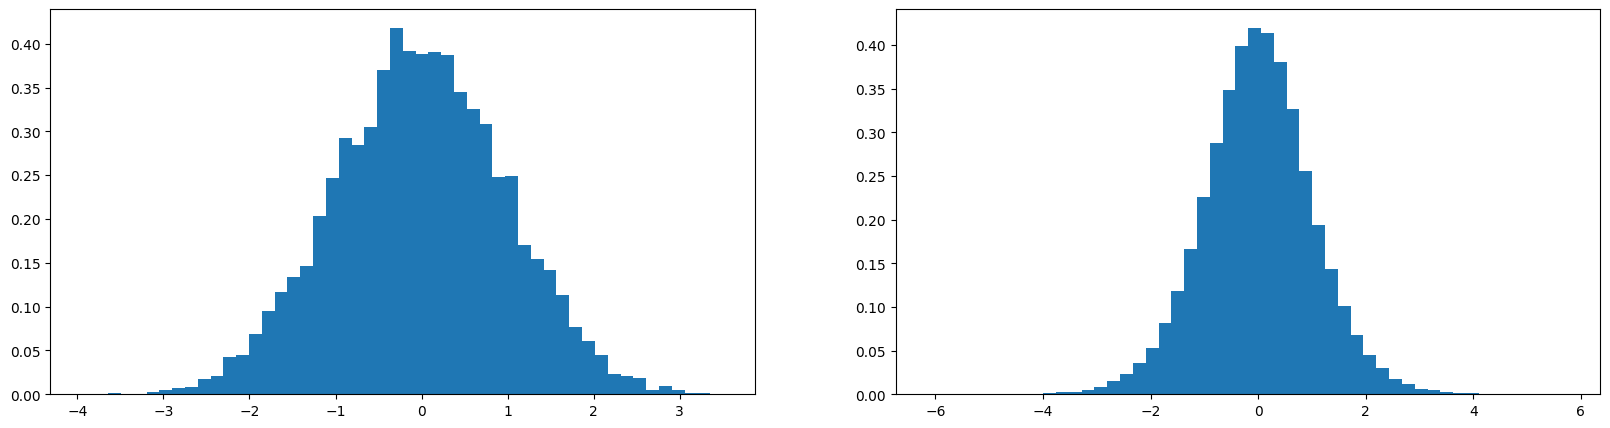

In [32]:
x = torch.randn(1000, 10) #1000 no with 10 dimensions
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

to further solidify it we calculate the kaiming init value to multiply which is the standard way

here we multiply it by

(5/3) / (30**0.5)

so 5/3 is what suitable for tanh non linearity and it will change if we use any other non linearity, 30 is the inputs, the no comes out to be 0.3

In [33]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn( (vocab_size, n_embd), generator=g)
W1 = torch.randn( (n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size) ** 0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch. randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p. requires_grad = True

11897


In [34]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = xtr[ix], ytr[ix] # batch X, Y

  # forward pass|
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3129
  10000/ 200000: 2.4228
  20000/ 200000: 2.3509
  30000/ 200000: 2.0158
  40000/ 200000: 2.0766
  50000/ 200000: 2.3837
  60000/ 200000: 2.2647
  70000/ 200000: 2.0855
  80000/ 200000: 1.9400
  90000/ 200000: 2.0193
 100000/ 200000: 2.4169
 110000/ 200000: 2.2000
 120000/ 200000: 2.0957
 130000/ 200000: 2.2537
 140000/ 200000: 2.0838
 150000/ 200000: 2.2849
 160000/ 200000: 2.0624
 170000/ 200000: 2.0430
 180000/ 200000: 2.2258
 190000/ 200000: 1.8990


In [35]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y ={
  'train': (xtr, ytr),
  'val': (xdev, ydev),
  'test': (xte, yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.037754774093628
val 2.1032512187957764


we got a very slight better loss

**batch normalisation**

so in batch normalisation we directly standardize the hpreacts

bngain and bnbias are just gain and add components, this will ensure each neurons firing value will be unit gaussians

In [52]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn( (vocab_size, n_embd), generator=g)
W1 = torch.randn( (n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size) ** 0.5)
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch. randn(vocab_size, generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p. requires_grad = True

12297


In [53]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = xtr[ix], ytr[ix] # batch X, Y

  # forward pass|
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact-bnmeani) / bnstdi + bnbias # batch normalisation

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


In [50]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [54]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y ={
  'train': (xtr, ytr),
  'val': (xdev, ydev),
  'test': (xte, yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  hpreact = bngain * (hpreact-bnmean_running) / bnstd_running + bnbias # batch normalisation
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)

  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.9836857318878174
val 3.0113582611083984
